In [18]:
# Installing requirements
!pip -q install pandas numpy networkx scikit-learn imbalanced-learn xgboost shap matplotlib openpyxl

import warnings, re
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("ready")

ready


loadin data From import

In [19]:
import os
FNAME = "Loans with Guarantors Data.xlsx"
path = FNAME if os.path.exists(FNAME) else (f"content/{FNAME}" if os.path.exists(f"data/{FNAME}") else None)
if path is None:
    from google.colab import files
    up = files.upload()
    path = list(up.keys())[0]
xl = pd.ExcelFile(path)
print("sheets:", xl.sheet_names)

sheets: ['Written Off', 'Normal']


In [20]:
combined = pd.concat([
    xl.parse("Written Off").assign(outcome="Written Off", label=1),
    xl.parse("Normal").assign(outcome="Repaid",       label=0),
], ignore_index=True)

# put the new columns first for readability
front = ["outcome", "label"]
combined = combined[front + [c for c in combined.columns if c not in front]]

combined.to_csv("loans_combined.csv", index=False)
print("merged shape:", combined.shape)
print(combined["outcome"].value_counts())
try:                                   # download in Colab (file is git-ignored, do not commit)
    from google.colab import files; files.download("loans_combined.csv")
except Exception:
    pass
combined.head()

merged shape: (2393, 18)
outcome
Repaid         2301
Written Off      92
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,outcome,label,Loan ID,Borrower ID,Guarantor ID,Date Guaranteed,Customer Opening Date,Disbursement Amount,Disbursement Date,Last Payment Date,Interest Rate,Non Paid Capital,Non Paid Interest,Non Paid Penalty,Non Paid Insurance,Days in Arrears,Savings,Salary
0,Written Off,1,Loan003,Client001,Guarantor052,2019-01-18,2007-07-07,800000,2019-01-18,2021-03-30,16,0,0,0,0,489,0,NaN
1,Written Off,1,Loan003,Client001,Guarantor024,2019-01-18,2007-07-07,800000,2019-01-18,2021-03-30,16,0,0,0,0,489,0,NaN
2,Written Off,1,Loan003,Client001,Guarantor050,2019-01-18,2007-07-07,800000,2019-01-18,2021-03-30,16,0,0,0,0,489,0,NaN
3,Written Off,1,Loan013,Client002,Guarantor001,2019-12-23,2007-07-07,1200000,2019-12-23,2025-04-25,13,0,0,0,0,648,19427,NaN
4,Written Off,1,Loan013,Client002,Guarantor032,2019-12-23,2007-07-07,1200000,2019-12-23,2025-04-25,13,0,0,0,0,648,19427,NaN


Display data

In [21]:
# Unify IDs: 'Client052' and 'Guarantor052' are the SAME member (the Guarantor prefix is a
# confirmed data-entry error). The trailing number is the member key.
num = lambda s: int(re.search(r"(\d+)$", str(s)).group(1))

def read(sheet, label):
    d = xl.parse(sheet); d["label"] = label; return d

raw = pd.concat([read("Written Off", 1), read("Normal", 0)], ignore_index=True)
raw["outcome"] = np.where(raw["label"] == 1, "Written Off", "Repaid")
raw["member"]   = raw["Borrower ID"].map(num)
raw["g_member"] = raw["Guarantor ID"].map(num)
for c in ["Date Guaranteed", "Customer Opening Date", "Disbursement Date", "Last Payment Date"]:
    raw[c] = pd.to_datetime(raw[c], errors="coerce")
raw["Salary"] = pd.to_numeric(raw["Salary"], errors="coerce")   # 'NULL' -> NaN
print("rows (loan-guarantor pairs):", raw.shape)
raw.head()

rows (loan-guarantor pairs): (2393, 20)


,Loan ID,Borrower ID,Guarantor ID,Date Guaranteed,Customer Opening Date,Disbursement Amount,Disbursement Date,Last Payment Date,Interest Rate,Non Paid Capital,Non Paid Interest,Non Paid Penalty,Non Paid Insurance,Days in Arrears,Savings,Salary,label,outcome,member,g_member
0,Loan003,Client001,Guarantor052,2019-01-18,2007-07-07,800000,2019-01-18,2021-03-30,16,0,0,0,0,489,0,NaN,1,Written Off,1,52
1,Loan003,Client001,Guarantor024,2019-01-18,2007-07-07,800000,2019-01-18,2021-03-30,16,0,0,0,0,489,0,NaN,1,Written Off,1,24
2,Loan003,Client001,Guarantor050,2019-01-18,2007-07-07,800000,2019-01-18,2021-03-30,16,0,0,0,0,489,0,NaN,1,Written Off,1,50
3,Loan013,Client002,Guarantor001,2019-12-23,2007-07-07,1200000,2019-12-23,2025-04-25,13,0,0,0,0,648,19427,NaN,1,Written Off,2,1
4,Loan013,Client002,Guarantor032,2019-12-23,2007-07-07,1200000,2019-12-23,2025-04-25,13,0,0,0,0,648,19427,NaN,1,Written Off,2,32


In [22]:
# Collapse to ONE row per loan, keeping the list of guarantor member-ids
loans = (raw.groupby("Loan ID").agg(
            member=("member", "first"), label=("label", "first"),
            amount=("Disbursement Amount", "first"), disb=("Disbursement Date", "first"),
            opened=("Customer Opening Date", "first"), last_pay=("Last Payment Date", "first"),
            rate=("Interest Rate", "first"), savings=("Savings", "first"),
            salary=("Salary", "first"), guarantors=("g_member", list))
         .reset_index())
loans["n_g"] = loans["guarantors"].map(len)
print(f"{len(loans)} loans | written-off={int(loans.label.sum())} "
      f"({100*loans.label.mean():.1f}%) | normal={int((1-loans.label).sum())}")
loans.head()

906 loans | written-off=35 (3.9%) | normal=871


,Loan ID,member,label,amount,disb,opened,last_pay,rate,savings,salary,guarantors,n_g
0,Loan001,11,1,590000,2018-04-25,2014-03-20,2025-10-23,13,40261,266903.000,"[39, 28, 686, 262]",4
1,Loan002,20,1,1580000,2019-01-16,2018-10-02,2021-02-17,14,0,243912.000,"[53, 21, 54, 241, 366]",5
2,Loan003,1,1,800000,2019-01-18,2007-07-07,2021-03-30,16,0,NaN,"[52, 24, 50, 417, 576]",5
3,Loan004,6,1,300000,2019-01-18,2011-04-13,2024-01-26,16,0,289061.000,"[2, 3, 22, 444, 484]",5
4,Loan005,16,1,1210000,2019-02-21,2017-05-16,2025-05-09,14,3903,157694.000,"[11, 24, 51, 114, 147]",5


Data Visualisations

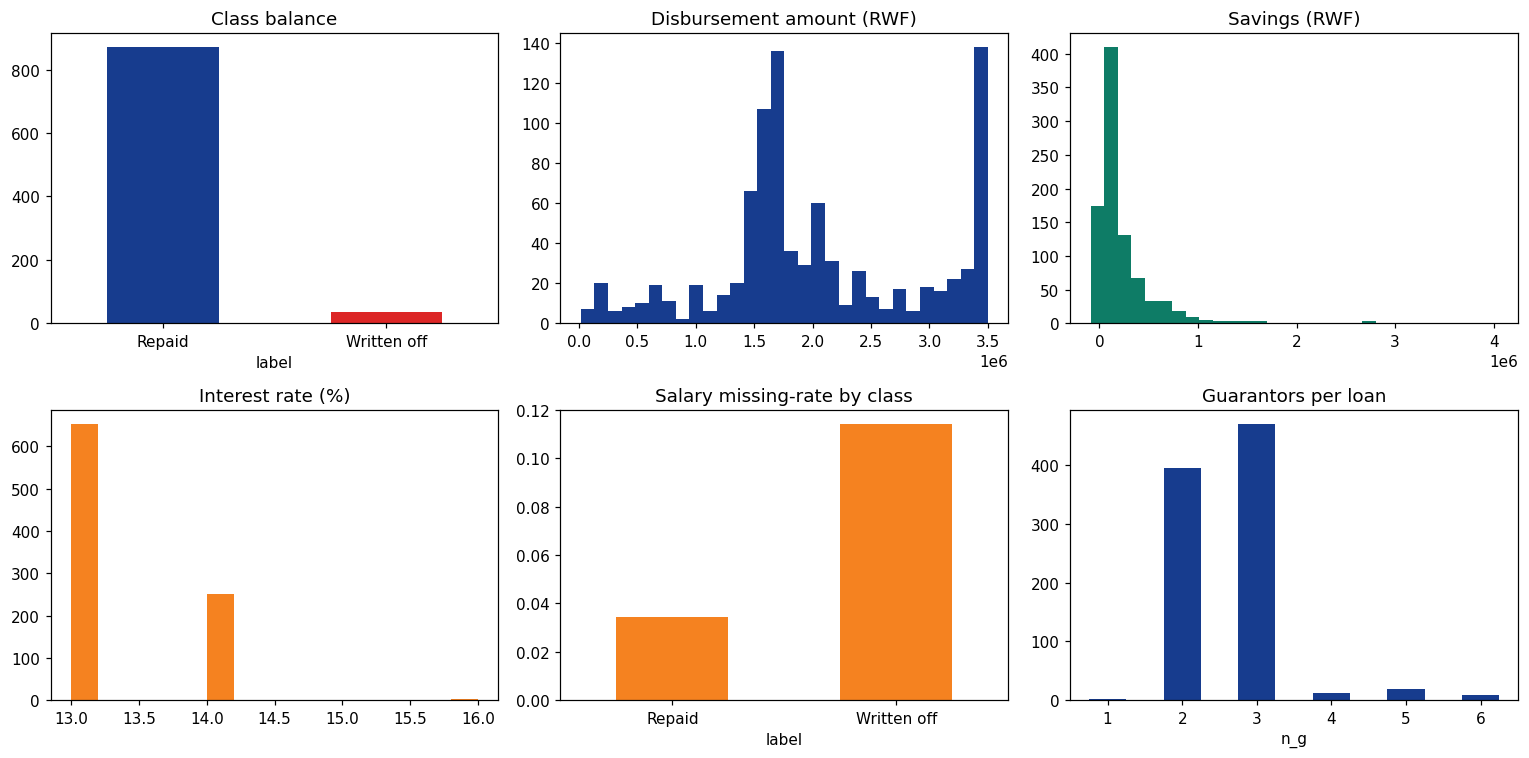

In [23]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
loans["label"].map({0: "Repaid", 1: "Written off"}).value_counts().plot.bar(
    ax=ax[0, 0], color=["#173C8E", "#DC2626"]); ax[0, 0].set_title("Class balance"); ax[0,0].tick_params(axis="x", rotation=0)
ax[0, 1].hist(loans["amount"].dropna(), bins=30, color="#173C8E"); ax[0, 1].set_title("Disbursement amount (RWF)")
ax[0, 2].hist(loans["savings"].dropna(), bins=30, color="#0E7C66"); ax[0, 2].set_title("Savings (RWF)")
ax[1, 0].hist(loans["rate"].dropna(), bins=15, color="#F58220"); ax[1, 0].set_title("Interest rate (%)")
(loans.assign(salary_missing=loans["salary"].isna()).groupby("label")["salary_missing"].mean()
   .plot.bar(ax=ax[1, 1], color="#F58220")); ax[1, 1].set_title("Salary missing-rate by class")
ax[1, 1].set_xticklabels(["Repaid", "Written off"], rotation=0)
loans["n_g"].value_counts().sort_index().plot.bar(ax=ax[1, 2], color="#173C8E")
ax[1, 2].set_title("Guarantors per loan"); ax[1, 2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

Feature Engineering

In [24]:
from bisect import bisect_left
from collections import defaultdict

# A member's "default became known" date = earliest last-payment among their written-off loans.
dd = (loans[loans.label == 1].dropna(subset=["last_pay"])
        .groupby("member")["last_pay"].min().to_dict())

# Guarantee edges (guarantor -> borrower) with the date the guarantee was made.
edges = [(int(g), int(b), pd.Timestamp(t))
         for g, b, t in raw[["g_member", "member", "Date Guaranteed"]].dropna().values]
edges_sorted = sorted(edges, key=lambda e: e[2])

# Each member's sorted outgoing-guarantee dates -> as-of "guarantor load" via binary search.
out_dates = defaultdict(list)
for g, b, t in edges: out_dates[g].append(t)
for k in out_dates: out_dates[k].sort()
def out_deg_asof(m, d): return bisect_left(out_dates.get(m, []), d)

# PageRank / degree on the network SNAPSHOT (only edges strictly before d), cached per date.
pr_cache = {}
def snapshot(d):
    if d in pr_cache: return pr_cache[d]
    G = nx.DiGraph()
    for g, b, t in edges_sorted:
        if t < d: G.add_edge(g, b)
        else: break
    pr = nx.pagerank(G) if G.number_of_nodes() else {}
    pr_cache[d] = (G, pr); return pr_cache[d]

def network_feats(row):
    d, gs, m, ng = row["disb"], row["guarantors"], row["member"], row["n_g"]
    if pd.isna(d):
        return pd.Series(dict(g_prior_default_rate=0, g_load_mean=0, g_load_max=0,
                              b_out_degree=0, b_in_degree=0, pagerank=0.0))
    G, pr = snapshot(d)
    g_pd  = np.mean([1.0 if (g in dd and dd[g] < d) else 0.0 for g in gs]) if ng else 0.0
    loads = [out_deg_asof(g, d) for g in gs] or [0]
    return pd.Series(dict(
        g_prior_default_rate=g_pd, g_load_mean=np.mean(loads), g_load_max=np.max(loads),
        b_out_degree=(G.out_degree(m) if m in G else 0),
        b_in_degree=(G.in_degree(m) if m in G else 0), pagerank=pr.get(m, 0.0)))

loans = pd.concat([loans, loans.apply(network_feats, axis=1)], axis=1)

# Individual (member) features available at approval
loans["loan_to_savings"] = loans["amount"] / (loans["savings"].fillna(0) + 1)
loans["salary_on_file"]  = loans["salary"].notna().astype(int)
loans["tenure_days"]     = (loans["disb"] - loans["opened"]).dt.days
loans["log_amount"]      = np.log1p(loans["amount"])
loans["n_guarantors"]    = loans["n_g"]
print("feature engineering done")
loans[["g_prior_default_rate", "g_load_max", "pagerank", "loan_to_savings", "tenure_days"]].describe().round(3)

feature engineering done


,g_prior_default_rate,g_load_max,pagerank,loan_to_savings,tenure_days
count,906.000,906.000,906.000,906.000,906.000
mean,0.011,1.937,0.001,81339.372,2527.925
std,0.069,1.554,0.002,464346.382,2059.509
min,0.000,0.000,0.000,-65.999,6.000
25%,0.000,1.000,0.000,6.766,802.750
50%,0.000,2.000,0.000,15.858,1634.000
75%,0.000,3.000,0.000,29.570,4430.250
max,0.667,8.000,0.036,3500000.000,15713.000


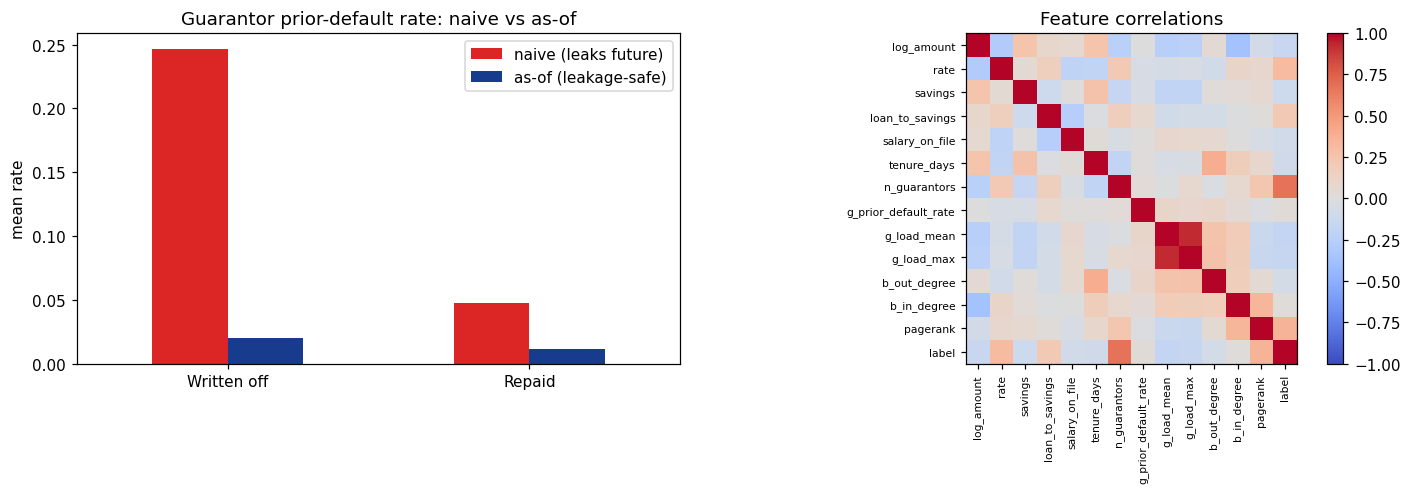

In [25]:
# Naive (timing-blind) vs as-of neighbour prior-default: shows why timing matters.
ever = set(dd)
loans["g_prior_default_naive"] = loans.apply(
    lambda r: np.mean([g in ever for g in r["guarantors"]]) if r["n_g"] else 0, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
comp = pd.DataFrame({
    "naive (leaks future)": [loans[loans.label==1]["g_prior_default_naive"].mean(),
                             loans[loans.label==0]["g_prior_default_naive"].mean()],
    "as-of (leakage-safe)": [loans[loans.label==1]["g_prior_default_rate"].mean(),
                             loans[loans.label==0]["g_prior_default_rate"].mean()],
}, index=["Written off", "Repaid"])
comp.plot.bar(ax=ax[0], color=["#DC2626", "#173C8E"]); ax[0].tick_params(axis="x", rotation=0)
ax[0].set_title("Guarantor prior-default rate: naive vs as-of"); ax[0].set_ylabel("mean rate")

feat_cols = ["log_amount","rate","savings","loan_to_savings","salary_on_file","tenure_days",
             "n_guarantors","g_prior_default_rate","g_load_mean","g_load_max",
             "b_out_degree","b_in_degree","pagerank","label"]
corr = loans[feat_cols].corr()
im = ax[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(feat_cols))); ax[1].set_xticklabels(feat_cols, rotation=90, fontsize=7)
ax[1].set_yticks(range(len(feat_cols))); ax[1].set_yticklabels(feat_cols, fontsize=7)
ax[1].set_title("Feature correlations"); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

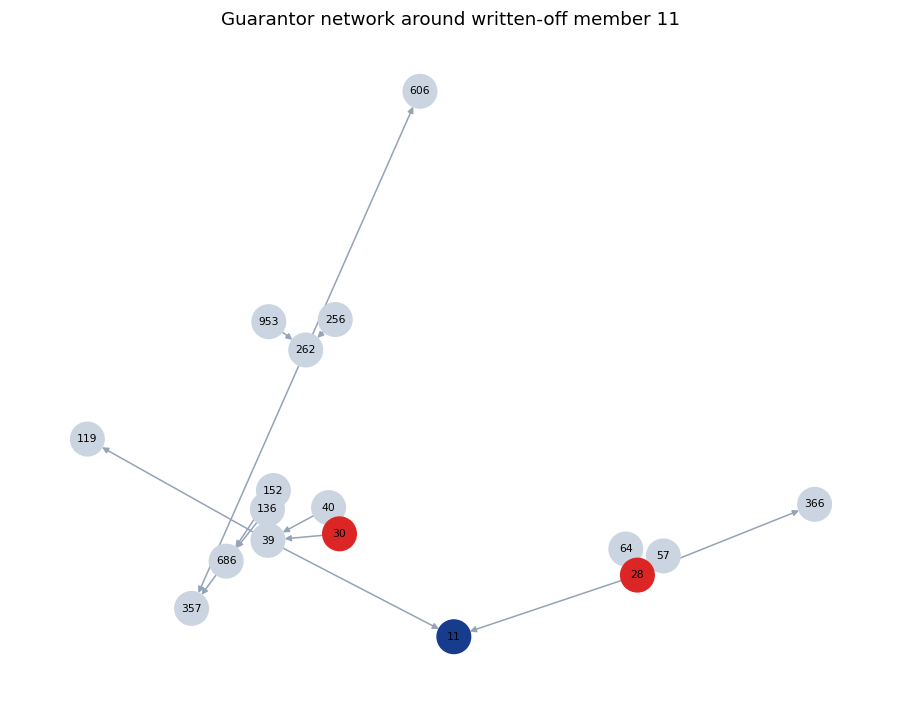

In [26]:
# Ego network around one written-off member (blue = the member, red = ever-defaulter, grey = others)
G_full = nx.DiGraph(); G_full.add_edges_from([(g, b) for g, b, t in edges])
ex = loans[loans.label == 1].iloc[0]
nodes = set([ex["member"]]) | set(ex["guarantors"])
for g in ex["guarantors"]:
    if g in G_full:
        nodes |= set(list(G_full.predecessors(g))[:2] + list(G_full.successors(g))[:2])
H = G_full.subgraph(nodes)
pos = nx.spring_layout(H, seed=RANDOM_STATE)
colors = ["#173C8E" if n == ex["member"] else ("#DC2626" if n in dd else "#cbd5e1") for n in H]
plt.figure(figsize=(8, 6))
nx.draw(H, pos, node_color=colors, with_labels=True, font_size=7, node_size=480,
        edge_color="#94a3b8", arrows=True, arrowsize=8)
plt.title(f"Guarantor network around written-off member {ex['member']}")
plt.show()

Model Architecture

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

BASE = ["log_amount", "rate", "savings", "loan_to_savings", "salary_on_file", "tenure_days"]
NET  = ["n_guarantors", "g_prior_default_rate", "g_load_mean", "g_load_max",
        "b_out_degree", "b_in_degree", "pagerank"]
y = loans["label"].values
pos, neg = int(y.sum()), int((1 - y).sum())

def build_models():
    smote = SMOTE(k_neighbors=3, random_state=RANDOM_STATE)
    return {
        "Logistic Regression": ImbPipeline([
            ("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()),
            ("smote", smote), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
        "Random Forest": ImbPipeline([
            ("imp", SimpleImputer(strategy="median")), ("smote", smote),
            ("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                           random_state=RANDOM_STATE))]),
        "XGBoost": ImbPipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                  scale_pos_weight=neg / pos, subsample=0.9, colsample_bytree=0.9,
                                  eval_metric="logloss", random_state=RANDOM_STATE))]),
    }
print(f"baseline features={len(BASE)}, augmented features={len(BASE+NET)} | positives={pos}, negatives={neg}")

baseline features=6, augmented features=13 | positives=35, negatives=871


initial performance and metrics

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["recall", "precision", "f1", "roc_auc", "average_precision", "accuracy"]

rows = []
for fs_name, cols in [("baseline (individual)", BASE), ("augmented (+network)", BASE + NET)]:
    for name in build_models():
        est = build_models()[name]
        res = cross_validate(est, loans[cols], y, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({"model": name, "features": fs_name,
                     **{m: res["test_" + m].mean() for m in scoring}})
results = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
results[["model", "features", "recall", "precision", "f1", "roc_auc", "average_precision", "accuracy"]]

,model,features,recall,precision,f1,roc_auc,average_precision,accuracy
0,Logistic Regression,baseline (individual),0.857,0.215,0.340,0.926,0.346,0.869
1,Random Forest,baseline (individual),0.571,0.446,0.465,0.959,0.590,0.955
2,XGBoost,baseline (individual),0.486,0.484,0.463,0.955,0.587,0.957
3,Logistic Regression,augmented (+network),0.943,0.975,0.956,0.999,0.988,0.997
4,Random Forest,augmented (+network),0.971,0.975,0.971,1.000,1.000,0.998
5,XGBoost,augmented (+network),1.000,0.975,0.987,1.000,1.000,0.999


baseline vs augumented

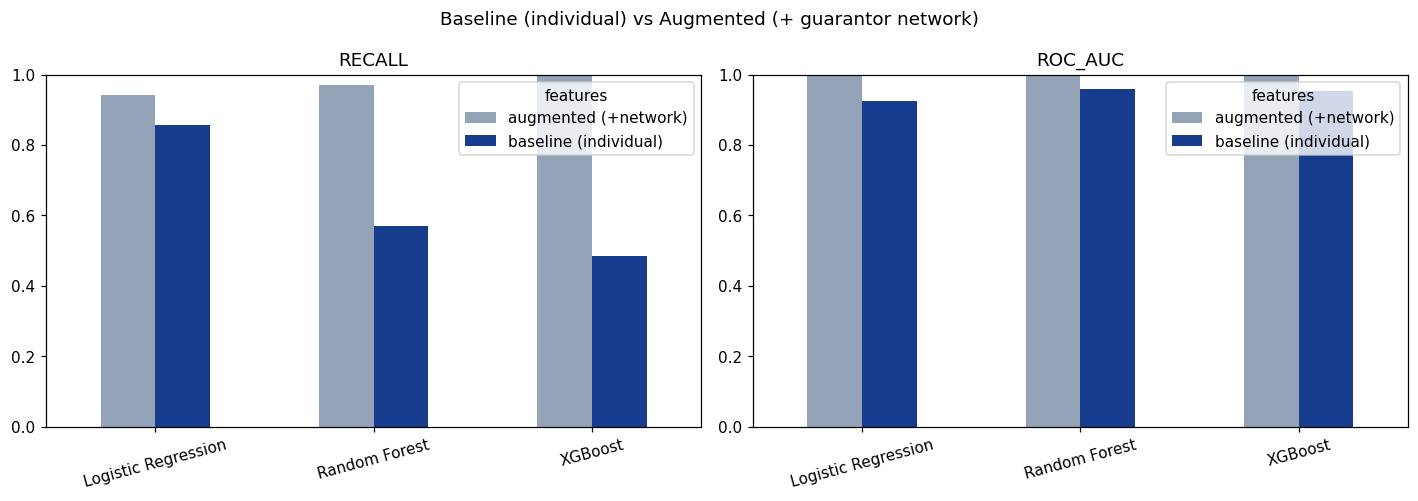

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for a, metric in zip(ax, ["recall", "roc_auc"]):
    piv = results.pivot(index="model", columns="features", values=metric)
    piv.plot.bar(ax=a, color=["#94a3b8", "#173C8E"]); a.set_title(metric.upper())
    a.set_ylim(0, 1); a.tick_params(axis="x", rotation=15); a.set_xlabel("")
plt.suptitle("Baseline (individual) vs Augmented (+ guarantor network)")
plt.tight_layout(); plt.show()

Confusion Matrix report

              precision    recall  f1-score   support

      Repaid      1.000     0.999     0.999       871
 Written off      0.972     1.000     0.986        35

    accuracy                          0.999       906
   macro avg      0.986     0.999     0.993       906
weighted avg      0.999     0.999     0.999       906



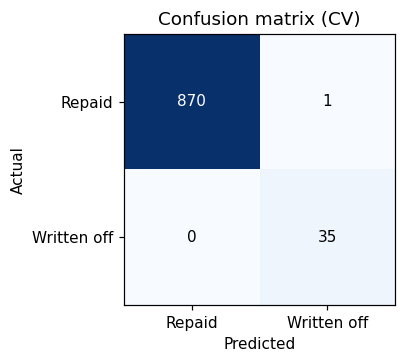

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
yp = cross_val_predict(build_models()["XGBoost"], loans[BASE + NET], y, cv=cv, method="predict")
print(classification_report(y, yp, target_names=["Repaid", "Written off"], digits=3))
cm = confusion_matrix(y, yp)
fig, a = plt.subplots(figsize=(4, 3.4)); im = a.imshow(cm, cmap="Blues")
a.set_xticks([0, 1]); a.set_xticklabels(["Repaid", "Written off"])
a.set_yticks([0, 1]); a.set_yticklabels(["Repaid", "Written off"])
a.set_xlabel("Predicted"); a.set_ylabel("Actual"); a.set_title("Confusion matrix (CV)")
for i in range(2):
    for j in range(2):
        a.text(j, i, cm[i, j], ha="center", va="center",
               color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

In [31]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

    Xn = loans[BASE + NET].fillna(loans[BASE + NET].median())
    Xs = StandardScaler().fit_transform(Xn)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    net = models.Sequential([
        layers.Input(shape=(Xs.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    net.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="binary_crossentropy", metrics=["AUC"])
    net.summary()
    net.fit(Xtr, ytr, validation_split=0.2, epochs=40, batch_size=32,
            class_weight={0: 1.0, 1: neg / pos}, verbose=0)
    proba = net.predict(Xte, verbose=0).ravel(); pred = (proba >= 0.5).astype(int)
    print(f"\nNN (augmented) test  recall={recall_score(yte, pred):.3f}  "
          f"precision={precision_score(yte, pred, zero_division=0):.3f}  "
          f"f1={f1_score(yte, pred, zero_division=0):.3f}  auc={roc_auc_score(yte, proba):.3f}")
except Exception as e:
    print("Neural-net section skipped (TensorFlow unavailable in this runtime):", e)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)


NN (augmented) test  recall=0.778  precision=0.875  f1=0.824  auc=0.999


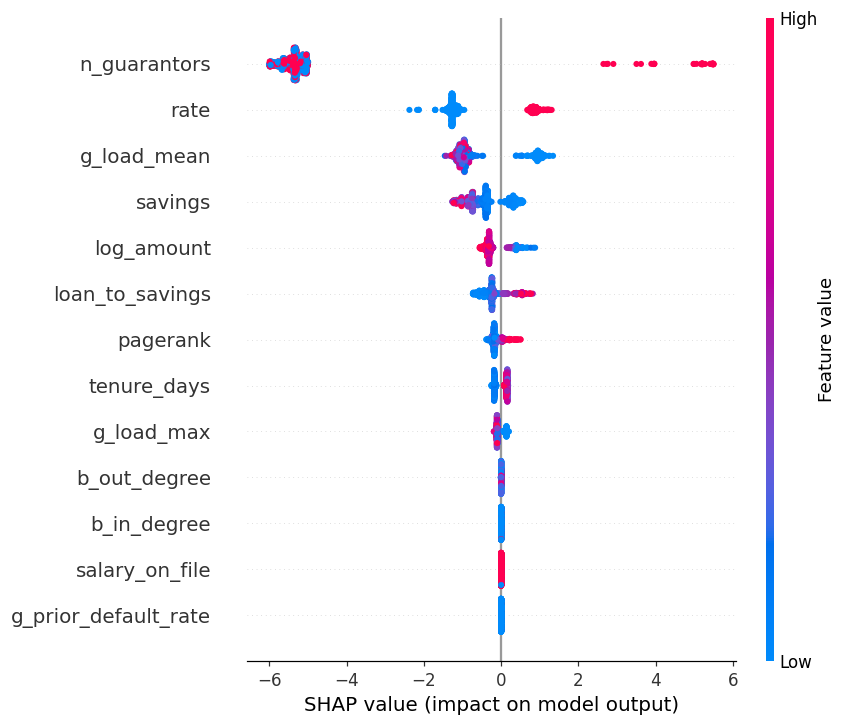

In [32]:
import shap
xgb = build_models()["XGBoost"]; xgb.fit(loans[BASE + NET], y)
clf = xgb.named_steps["clf"]
Ximp = xgb.named_steps["imp"].transform(loans[BASE + NET])
sv = shap.TreeExplainer(clf).shap_values(Ximp)
shap.summary_plot(sv, features=Ximp, feature_names=BASE + NET, show=True)

In [33]:
import joblib, os
os.makedirs("models", exist_ok=True)
final = build_models()["XGBoost"]; final.fit(loans[BASE + NET], y)
joblib.dump({"model": final, "features": BASE + NET}, "models/guarantorlens_xgb.joblib")
print("saved -> models/guarantorlens_xgb.joblib")
try:
    from google.colab import files; files.download("models/guarantorlens_xgb.joblib")
except Exception:
    pass

saved -> models/guarantorlens_xgb.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>